In [10]:
import os
import yaml
from glob import glob
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from utils import parse_utk_filename, age_to_group, AGE_GROUPS, RACE_MAP

In [11]:
def load_config(path="train_config.yaml"):
    """Load configuration file"""
    if not os.path.exists(path):
        raise FileNotFoundError(f"Config file not found: {path}")
    with open(path, "r") as f:
        cfg = yaml.safe_load(f)
    return cfg

def collect_files(data_dirs):
    """Collect all image files from data directories"""
    all_files = []
    seen_basenames = set()
    
    for d in data_dirs:
        if not os.path.isdir(d):
            print(f"Warning: data_dir not found: {d} (skipping)")
            continue
        candidates = sorted(glob(os.path.join(d, "*.jpg")) + glob(os.path.join(d, "*.png")))
        for f in candidates:
            bn = os.path.basename(f)
            if bn in seen_basenames:
                continue
            seen_basenames.add(bn)
            all_files.append(f)
    
    return all_files

In [12]:
cfg = load_config()
data_dirs = cfg.get("data_dirs", [])
all_files = collect_files(data_dirs)
print(f"Found {len(all_files)} total images")

Found 23623 total images


In [13]:
metas_all = []
failed_files = []

for f in all_files:
    try:
        meta = parse_utk_filename(f)
        metas_all.append(meta)
    except ValueError as e:
        failed_files.append((f, str(e)))

print(f"Parsed metadata for {len(metas_all)} images and failed on {len(failed_files)} images.")

Parsed metadata for 23618 images and failed on 5 images.


In [14]:
# Filter valid gender labels and prepare data
valid_mask = []
bad_files = []

for m in metas_all:
    g = m.get("gender", None)
    if g in (0, 1):
        valid_mask.append(True)
    else:
        valid_mask.append(False)
        bad_files.append(m)

# Filter to valid files only
metas = [m for m, ok in zip(metas_all, valid_mask) if ok]
valid_files = [f for f, ok in zip(all_files, valid_mask) if ok]

# Extract labels for analysis
genders = [m["gender"] for m in metas]
ages = [m["age"] for m in metas]
races = [m["race"] for m in metas]
age_groups = [age_to_group(age) for age in ages]

print(f"Total samples: {len(genders)}")

Total samples: 23618


In [15]:
# Overall Gender Distribution Analysis
def analyze_overall_gender_balance():
    gender_counts = Counter(genders)
    total = len(genders)
    
    print(f"Male (0): {gender_counts[0]} ({gender_counts[0]/total*100}%)")
    print(f"Female (1): {gender_counts[1]} ({gender_counts[1]/total*100}%)")
    
    # Calculate imbalance ratio
    minority_class = min(gender_counts.values())
    majority_class = max(gender_counts.values())
    gender_ratio = majority_class / minority_class
    
    print(f"\nGender Ratio: {gender_ratio:.2f}:1")
    
    if gender_ratio > 2.0:
        print("High Imbalance")
    elif gender_ratio > 1.5:
        print("Moderate Imbalance")
    else:
        print("Balanced dataset")
    
    return gender_counts, gender_ratio

gender_counts, overall_gender_ratio = analyze_overall_gender_balance()

Male (0): 12329 (52.201710559742565%)
Female (1): 11289 (47.79828944025743%)

Gender Ratio: 1.09:1
Balanced dataset


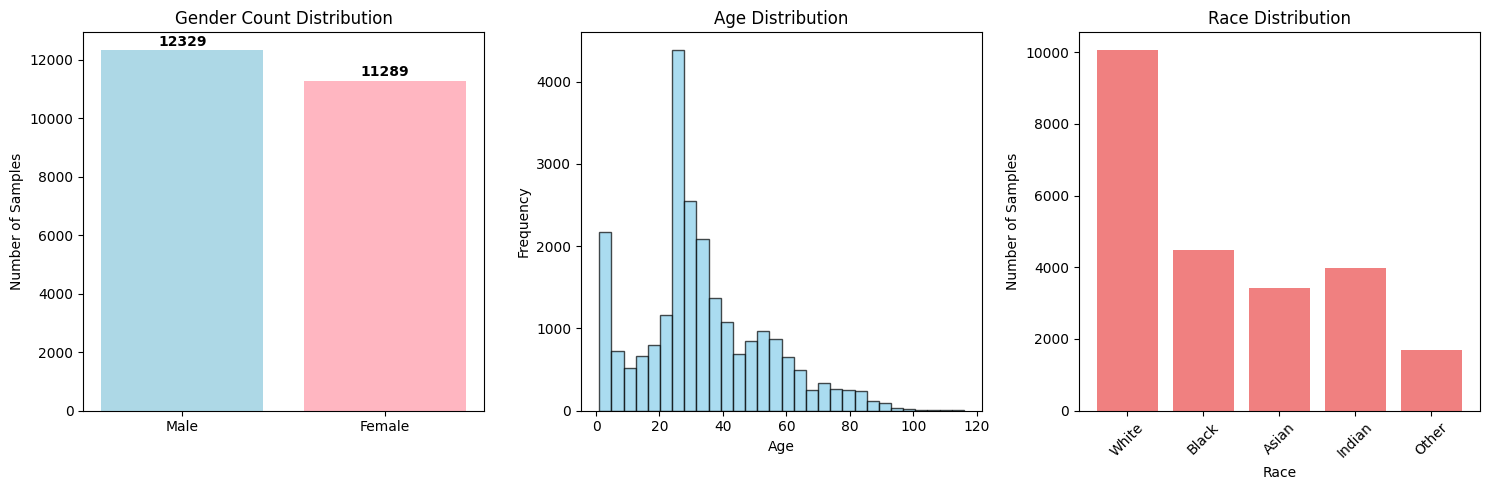

In [27]:
# Gender Distribution Visualization
plt.figure(figsize=(15, 5))

# Gender bar chart
plt.subplot(1, 3, 1)
colors = ['lightblue', 'lightpink']
plt.bar(['Male', 'Female'], [gender_counts[0], gender_counts[1]], color=colors)
plt.title('Gender Count Distribution')
plt.ylabel('Number of Samples')
for i, v in enumerate([gender_counts[0], gender_counts[1]]):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontweight='bold')

# Age distribution
plt.subplot(1, 3, 2)
plt.hist(ages, bins=30, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

# Race distribution
plt.subplot(1, 3, 3)
race_counts = Counter(races)
race_labels = [RACE_MAP.get(race_code, f"Code_{race_code}") for race_code in sorted(race_counts.keys())]
race_values = [race_counts[race_code] for race_code in sorted(race_counts.keys())]
plt.bar(race_labels, race_values, color='lightcoral')
plt.title('Race Distribution')
plt.xlabel('Race')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [17]:
# 3. Gender Distribution by Age Groups - Analysis and Visualization
def analyze_age_group_gender_balance():
    age_gender_matrix = defaultdict(lambda: defaultdict(int))
    for age_grp, gender in zip(age_groups, genders):
        age_gender_matrix[age_grp][gender] += 1
    
    imbalanced_groups = []
    age_data = []
    
    for age_grp in AGE_GROUPS.keys():
        if age_grp in age_gender_matrix:
            male_count = age_gender_matrix[age_grp][0]
            female_count = age_gender_matrix[age_grp][1]
            total_age = male_count + female_count
            
            if female_count > 0:
                ratio = male_count / female_count
                
                if ratio > 2.0 or ratio < 0.5:
                    imbalanced_groups.append(age_grp)
                elif ratio > 1.5 or ratio < 0.67:
                    imbalanced_groups.append(age_grp)
            else:
                imbalanced_groups.append(age_grp)
                
            age_data.append({
                'age_group': age_grp,
                'male': male_count,
                'female': female_count,
                'total': total_age,
                'ratio': ratio if female_count > 0 else float('inf')
            })
    
    return age_data, imbalanced_groups

age_data, age_imbalanced_groups = analyze_age_group_gender_balance()

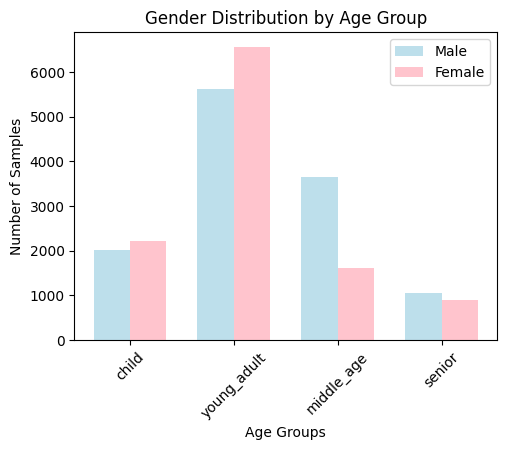

In [25]:
# Age Group Gender Distribution Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
age_groups_list = [d['age_group'] for d in age_data]
male_counts = [d['male'] for d in age_data]
female_counts = [d['female'] for d in age_data]

x = range(len(age_groups_list))
width = 0.35
plt.bar([i - width/2 for i in x], male_counts, width, label='Male', color='lightblue', alpha=0.8)
plt.bar([i + width/2 for i in x], female_counts, width, label='Female', color='lightpink', alpha=0.8)
plt.xlabel('Age Groups')
plt.ylabel('Number of Samples')
plt.title('Gender Distribution by Age Group')
plt.xticks(x, age_groups_list, rotation=45)
plt.legend()


In [ ]:
# Gender Distribution by Race - Analysis and Visualization
def analyze_race_gender_balance():
    race_gender_matrix = defaultdict(lambda: defaultdict(int))
    for race, gender in zip(races, genders):
        race_gender_matrix[race][gender] += 1
    
    imbalanced_races = []
    race_data = []
    
    for race_code in sorted(race_gender_matrix.keys()):
        race_name = RACE_MAP.get(race_code, f"Code_{race_code}")
        male_count = race_gender_matrix[race_code][0]
        female_count = race_gender_matrix[race_code][1]
        total_race = male_count + female_count
        
        if female_count > 0:
            ratio = male_count / female_count
            
            if ratio > 2.0 or ratio < 0.5:
                imbalanced_races.append(race_name)
            elif ratio > 1.5 or ratio < 0.67:
                imbalanced_races.append(race_name)
        else:
            imbalanced_races.append(race_name)
            ratio = float('inf')
            
        race_data.append({
            'race': race_name,
            'race_code': race_code,
            'male': male_count,
            'female': female_count,
            'total': total_race,
            'ratio': ratio
        })
    
    return race_data, imbalanced_races

race_data, race_imbalanced_groups = analyze_race_gender_balance()

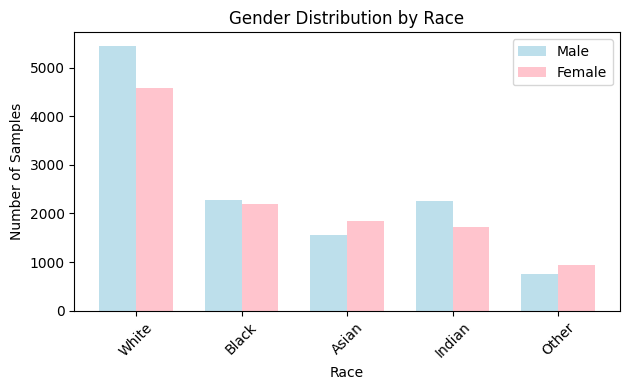

In [28]:
# Race Gender Distribution Plots
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
race_names = [d['race'] for d in race_data]
race_male_counts = [d['male'] for d in race_data]
race_female_counts = [d['female'] for d in race_data]

x = range(len(race_names))
width = 0.35
plt.bar([i - width/2 for i in x], race_male_counts, width, label='Male', color='lightblue', alpha=0.8)
plt.bar([i + width/2 for i in x], race_female_counts, width, label='Female', color='lightpink', alpha=0.8)
plt.xlabel('Race')
plt.ylabel('Number of Samples')
plt.title('Gender Distribution by Race')
plt.xticks(x, race_names, rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

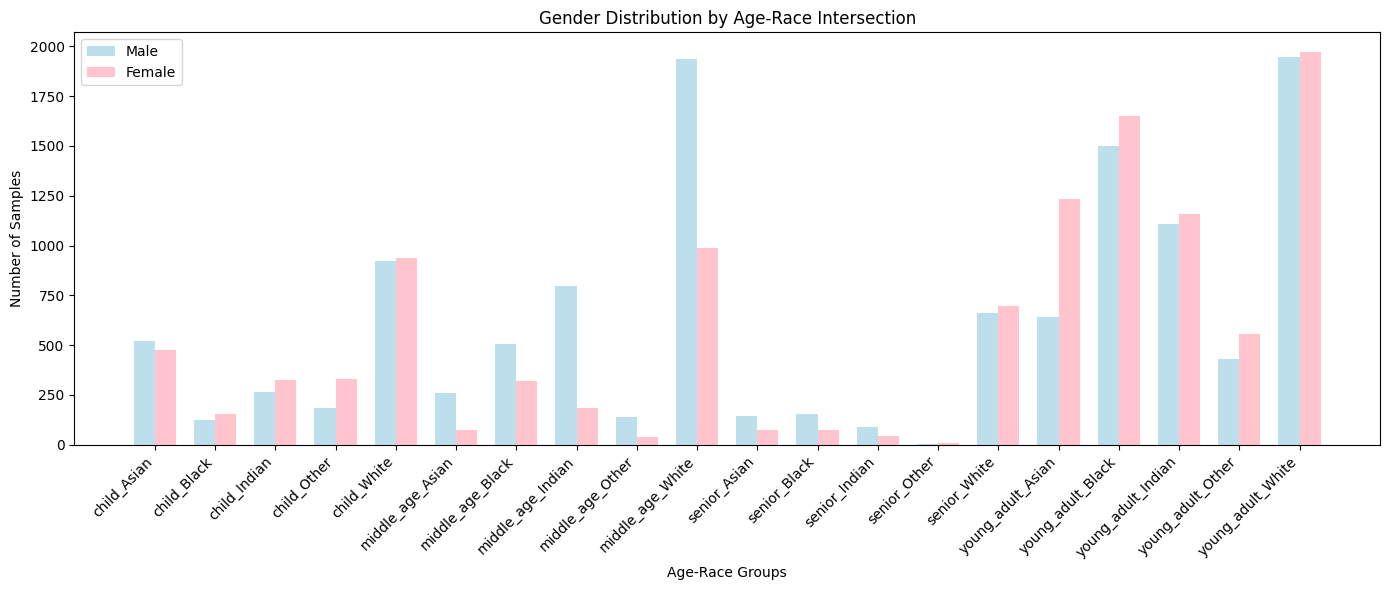

In [21]:
# 5. Age-Race Intersection Analysis
def analyze_age_race_intersection():
    age_race_gender = defaultdict(lambda: defaultdict(int))
    for age_grp, race, gender in zip(age_groups, races, genders):
        key = f"{age_grp}_{RACE_MAP.get(race, f'Code_{race}')}"
        age_race_gender[key][gender] += 1
    
    high_imbalance_groups = []
    intersection_data = []
    
    for key in sorted(age_race_gender.keys()):
        male_count = age_race_gender[key][0]
        female_count = age_race_gender[key][1]
        total_group = male_count + female_count
        
        if total_group < 5:  # Skip very small groups for clarity
            continue
            
        if female_count > 0:
            ratio = male_count / female_count
            if ratio > 2.0 or ratio < 0.5:
                high_imbalance_groups.append(key)
            elif ratio > 1.5 or ratio < 0.67:
                pass  # moderate imbalance
        else:
            high_imbalance_groups.append(key)
            ratio = float('inf')
            
        intersection_data.append({
            'group': key,
            'male': male_count,
            'female': female_count,
            'total': total_group,
            'ratio': ratio
        })
    
    return intersection_data, high_imbalance_groups

intersection_data, high_imbalance_groups = analyze_age_race_intersection()

if intersection_data:
    plt.figure(figsize=(14, 6))
    
    groups = [d['group'] for d in intersection_data]
    male_counts = [d['male'] for d in intersection_data]
    female_counts = [d['female'] for d in intersection_data]
    
    x = range(len(groups))
    width = 0.35
    plt.bar([i - width/2 for i in x], male_counts, width, label='Male', color='lightblue', alpha=0.8)
    plt.bar([i + width/2 for i in x], female_counts, width, label='Female', color='lightpink', alpha=0.8)
    plt.xlabel('Age-Race Groups')
    plt.ylabel('Number of Samples')
    plt.title('Gender Distribution by Age-Race Intersection')
    plt.xticks(x, groups, rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

## Observation:

We do not see any significant imbalance in the dataset. The number of male and female face images seem to be balanced. The only imbalance we can see is in the number of images for middle age white person faces i.e. faces of people aged 40-64.